# FHI — Expert Optimization v2
## Target: Macro F1 ≥ 0.91 (merged approach1 + FHI_Optimization insights)

### What's new vs v1
| Addition | Source | Expected ΔF1 |
|----------|--------|-------------|
| Country z-score + percentile features | approach1 | +0.02–0.03 |
| `fhi_rule_bin` heuristic feature | approach1 | +0.01–0.02 |
| `stress_score`, `credit_access_vulnerability` | approach1 | +0.01 |
| KNN imputation (vs median) | approach1 | +0.005–0.01 |
| Probability calibration (isotonic) | approach1 | +0.01–0.02 |
| Country-specific models | approach1 | +0.01–0.03 |
| HistGradientBoosting in ensemble | approach1 | +0.005–0.01 |
| All v1 techniques retained | v1 | +0.08–0.15 |


In [1]:
%pip install numpy pandas matplotlib seaborn scipy scikit-learn imbalanced-learn xgboost lightgbm catboost optuna --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Imports & Setup

In [4]:
import warnings, re
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
pd.set_option("display.max_columns", 60)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

from copy import deepcopy
from scipy.optimize import minimize
from scipy.stats import percentileofscore

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, log_loss, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import clone

from imblearn.over_sampling import SMOTE

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

DATA_DIR     = "/home/agbelgaid/Documents/WORKSPACE/Financial-Health-Prediction-Challenge/data"
SEED         = 42
N_FOLDS      = 5
TARGET       = "Target"
TARGET_ORDER = ["Low", "Medium", "High"]
TARGET_MAP   = {"Low": 0, "Medium": 1, "High": 2}
TARGET_IMAP  = {0: "Low", 1: "Medium", 2: "High"}

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
print("Imports OK.")


Imports OK.


## 2. Data Loading & Cleaning

In [5]:
train_raw = pd.read_csv(f"{DATA_DIR}/Train.csv")
test_raw  = pd.read_csv(f"{DATA_DIR}/Test.csv")
sample    = pd.read_csv(f"{DATA_DIR}/SampleSubmission.csv")

# ── Normalise text (smart quotes, Don't know variants, Used to have) ──────────
def clean_text(x):
    if pd.isna(x): return x
    x = str(x).strip()
    x = x.replace("\u2019","'").replace("\u2018","'").replace("?","'")
    x = re.sub(r"don.{0,2}t know.*", "Don't know", x, flags=re.IGNORECASE)
    x = re.sub(r"do not know.*",     "Don't know", x, flags=re.IGNORECASE)
    x = re.sub(r"used to have.*",    "Used to have", x, flags=re.IGNORECASE)
    return x.strip()

def clean_df(df):
    df = df.copy()
    for col in df.select_dtypes("object").columns:
        if col != "ID": df[col] = df[col].apply(clean_text)
    return df

train_raw = clean_df(train_raw)
test_raw  = clean_df(test_raw)

# ── Quantile clipping 0.1%–99.9% (tighter than baseline 1%–99%) ──────────────
FIN_COLS = ["personal_income", "business_expenses", "business_turnover"]
AGE_COLS = ["business_age_years", "business_age_months"]
clip_bounds = {}
for col in FIN_COLS + AGE_COLS:
    if col not in train_raw.columns: continue
    s = train_raw[col].dropna()
    clip_bounds[col] = (float(s.quantile(0.001)), float(s.quantile(0.999)))

def apply_clips(df, bounds):
    df = df.copy()
    for col, (lo, hi) in bounds.items():
        if col in df.columns:
            df[col] = df[col].clip(lower=lo, upper=hi)
    return df

train_raw = apply_clips(train_raw, clip_bounds)
test_raw  = apply_clips(test_raw,  clip_bounds)

print(f"Train: {train_raw.shape}   Test: {test_raw.shape}")
print(train_raw[TARGET].value_counts())


Train: (9618, 39)   Test: (2405, 38)
Target
Low       6280
Medium    2868
High       470
Name: count, dtype: int64


## 3. Feature Engineering

### Two-part FE
1. **Structural features** (no leakage) — ratios, composites, missing indicators
2. **Country-contextual features** (fit on train, transform test) — z-scores, percentile ranks

Additions from approach1:
- `fhi_rule_bin` — heuristic FHI label (Low/Medium/High) based on access+stress+profit thresholds
- `stress_score` — sum of worried_shutdown + cash_flow + problem_sourcing
- `credit_access_vulnerability` — `(1 - formal_acc) × (0.5 + informal_acc)`
- `operational_profitability_margin` — clipped profit margin [-1, 1]
- `stress_x_expense_ratio` + `access_x_log_turnover` cross-features
- Country z-score and percentile for all financial columns


In [6]:
PRODUCT_COLS   = ["motor_vehicle_insurance","has_mobile_money","has_credit_card",
                  "has_loan_account","has_internet_banking","has_debit_card",
                  "medical_insurance","funeral_insurance","uses_friends_family_savings",
                  "uses_informal_lender"]
INSURANCE_COLS = ["motor_vehicle_insurance","medical_insurance","funeral_insurance","has_insurance"]
BANKING_COLS   = ["has_mobile_money","has_credit_card","has_loan_account",
                  "has_internet_banking","has_debit_card"]
ATTITUDE_COLS  = ["attitude_stable_business_environment","attitude_worried_shutdown",
                  "attitude_satisfied_with_achievement","attitude_more_successful_next_year"]
PERCEPTION_COLS= ["perception_insurance_doesnt_cover_losses","perception_cannot_afford_insurance",
                  "perception_insurance_companies_dont_insure_businesses_like_yours",
                  "perception_insurance_important"]

HIGH_MISS_COLS = [c for c in train_raw.columns
                  if c not in ("ID", TARGET) and train_raw[c].isnull().mean() > 0.20]

def engineer_structural(df):
    """All features that can be computed without train/test leakage."""
    df = df.copy()
    eps = 1.0

    # ── Financial ratios ──────────────────────────────────────────────────────
    df["business_age_total"] = df["business_age_years"].fillna(0) + df["business_age_months"].fillna(0)/12
    df["log_income"]   = np.log1p(df["personal_income"].clip(lower=0))
    df["log_expenses"] = np.log1p(df["business_expenses"].clip(lower=0))
    df["log_turnover"] = np.log1p(df["business_turnover"].clip(lower=0))
    df["profit_proxy"] = df["business_turnover"].fillna(0) - df["business_expenses"].fillna(0)
    df["log_profit"]   = np.log1p(df["profit_proxy"].clip(lower=0))
    df["expense_ratio"]                = df["business_expenses"] / (df["business_turnover"] + eps)
    df["income_turnover_ratio"]        = df["personal_income"]   / (df["business_turnover"] + eps)
    df["income_expense_ratio"]         = df["personal_income"]   / (df["business_expenses"] + eps)
    df["turnover_per_year"]            = df["business_turnover"] / (df["business_age_total"] + eps)
    df["operational_profitability_margin"] = (
        (df["business_turnover"] - df["business_expenses"]) /
        (df["business_turnover"].fillna(0) + 1e-9)
    ).clip(-1, 1)

    # ── Financial product access (Have now=3, Used to have=2, Never had=1) ────
    # Using approach1 scale: 3/2/1/NaN so "Have now" clearly dominates
    prod_map = {"Have now": 3, "Used to have": 2, "Never had": 1, "Don't know": np.nan}
    for col in PRODUCT_COLS:
        if col in df.columns:
            df[f"{col}_score"] = df[col].map(prod_map)

    score_cols = [f"{c}_score" for c in PRODUCT_COLS if f"{c}_score" in df.columns]
    n_valid = df[score_cols].notna().sum(axis=1)
    df["financial_access_score"] = np.where(
        n_valid > 0,
        df[score_cols].sum(axis=1, min_count=1) / n_valid,
        np.nan
    )

    ins_s   = [f"{c}_score" for c in ["motor_vehicle_insurance","medical_insurance","funeral_insurance"] if f"{c}_score" in df.columns]
    bank_s  = [f"{c}_score" for c in ["has_mobile_money","has_credit_card","has_loan_account","has_internet_banking","has_debit_card"] if f"{c}_score" in df.columns]
    infrm_s = [f"{c}_score" for c in ["uses_friends_family_savings","uses_informal_lender"] if f"{c}_score" in df.columns]

    df["insurance_product_score"] = df[ins_s].mean(axis=1)   if ins_s   else np.nan
    df["banking_product_score"]   = df[bank_s].mean(axis=1)  if bank_s  else np.nan
    df["informal_access_score"]   = df[infrm_s].mean(axis=1) if infrm_s else np.nan

    # Count of products "Have now"
    df["num_products_have_now"] = (df[score_cols] == 3).sum(axis=1)
    df["num_insurance_have_now"] = (df[ins_s] == 3).sum(axis=1) if ins_s else 0

    # Formal finance access
    df["uses_formal_finance"] = (
        (df["has_credit_card"]     == "Have now").astype(int) +
        (df["has_loan_account"]    == "Have now").astype(int) +
        (df["has_internet_banking"]== "Have now").astype(int) +
        (df["has_debit_card"]      == "Have now").astype(int)
    )

    # ── Formalisation score ───────────────────────────────────────────────────
    df["formalization_score"] = (
        (df["compliance_income_tax"] == "Yes").astype(int) +
        (df["keeps_financial_records"].isin(["Yes","Yes, always","Yes, sometimes"])).astype(int) +
        df["uses_formal_finance"]
    )

    # ── Stress score (approach1): 3 financial-stress signals ─────────────────
    df["stress_score"] = (
        (df["attitude_worried_shutdown"]  == "Yes").astype(int) +
        (df["current_problem_cash_flow"]  == "Yes").astype(int) +
        (df["problem_sourcing_money"]     == "Yes").astype(int)
    )

    # ── Credit access vulnerability (approach1) ───────────────────────────────
    formal_acc  = df["financial_access_score"].fillna(0)
    informal_acc= df["informal_access_score"].fillna(0)
    df["credit_access_vulnerability"] = (1 - formal_acc) * (0.5 + informal_acc)

    # ── Attitude composites ───────────────────────────────────────────────────
    pos_att = ["attitude_stable_business_environment","attitude_more_successful_next_year",
               "attitude_satisfied_with_achievement"]
    for col in pos_att:
        df[f"{col}_bin"] = (df[col] == "Yes").astype(int)
    df["positive_attitude"]   = df[[f"{c}_bin" for c in pos_att]].sum(axis=1)
    df["worried_shutdown"]    = (df["attitude_worried_shutdown"] == "Yes").astype(int)
    df["insurance_engaged"]   = (
        (df["perception_insurance_important"] == "Yes").astype(int) +
        (df["has_insurance"] == "Yes").astype(int)
    )
    df["insurance_barrier_score"] = (
        (df["perception_cannot_afford_insurance"] == "Yes").astype(int) +
        (df["perception_insurance_doesnt_cover_losses"] == "Yes").astype(int) +
        (df["perception_insurance_companies_dont_insure_businesses_like_yours"] == "Yes").astype(int)
    )

    # ── Demographics ──────────────────────────────────────────────────────────
    df["is_male"]           = (df["owner_sex"] == "Male").astype(int)
    df["age_sq"]            = df["owner_age"] ** 2
    df["age_log"]           = np.log1p(df["owner_age"])
    df["age_x_biz_age"]     = df["owner_age"].fillna(0) * df["business_age_total"]

    # ── Cross-feature interactions (approach1) ────────────────────────────────
    df["stress_x_expense_ratio"]  = df["stress_score"] * df["expense_ratio"].clip(0, 5).fillna(0)
    df["access_x_log_turnover"]   = df["financial_access_score"].fillna(0) * df["log_turnover"].fillna(0)
    df["owner_age_x_products"]    = df["owner_age"].fillna(0) * df["num_products_have_now"].fillna(0)

    # ── FHI rule bin (approach1 heuristic) ────────────────────────────────────
    # High: good financial access + low stress + profitable
    # Medium: moderate access + manageable stress
    acc   = df["financial_access_score"].fillna(0)
    stress= df["stress_score"].fillna(0)
    etr   = df["expense_ratio"].fillna(1).clip(0, 1)
    profit_ok = (1 - etr) >= 0.10
    is_high   = (acc >= 0.5) & (stress <= 1) & profit_ok
    is_medium = ((acc >= 0.3) & (stress <= 2)) | ((acc >= 0.2) & (stress <= 1))
    rule_bin  = np.zeros(len(df), dtype=int)
    rule_bin[is_medium & ~is_high] = 1
    rule_bin[is_high]              = 2
    df["fhi_rule_bin"] = rule_bin

    # ── Missing indicators ────────────────────────────────────────────────────
    for col in HIGH_MISS_COLS:
        df[f"miss_{col}"] = df[col].isnull().astype(int)
    for block, cols in [("insurance", INSURANCE_COLS), ("banking", BANKING_COLS),
                        ("attitude", ATTITUDE_COLS), ("perception", PERCEPTION_COLS)]:
        mc = [c for c in cols if c in df.columns]
        df[f"{block}_miss_rate"] = df[mc].isnull().mean(axis=1)
    df["n_missing"] = df.isnull().sum(axis=1)

    # ── Country × insurance interaction ──────────────────────────────────────
    df["country_x_insurance"] = df["country"].astype(str) + "_" + df["has_insurance"].fillna("Missing")

    return df

train_fe = engineer_structural(train_raw)
test_fe  = engineer_structural(test_raw)
new_cols = [c for c in train_fe.columns if c not in train_raw.columns]
print(f"Structural features added: {len(new_cols)}")


Structural features added: 78


In [7]:
# ── Country-contextual features (fit on train, apply to both) ────────────────
def fit_country_features(train_df, fin_cols):
    """Compute per-country mean/std of log-transformed financial columns."""
    params = {}
    for col in fin_cols:
        if col not in train_df.columns or "country" not in train_df.columns:
            continue
        log_vals = np.log1p(train_df[col].clip(lower=0).fillna(0))
        grp = train_df.assign(_v=log_vals).groupby("country")["_v"].agg(["mean","std"])
        grp["std"] = grp["std"].replace(0, np.nan).fillna(1.0)
        params[col] = grp.to_dict("index")
        # Store raw values for percentile calculation
        params[f"{col}_vals"] = {}
        for c in train_df["country"].dropna().unique():
            mask = train_df["country"] == c
            params[f"{col}_vals"][str(c)] = train_df.loc[mask, col].dropna().values
    return params

def add_country_features(df, params, fin_cols, is_train=False):
    df = df.copy()
    for col in fin_cols:
        if col not in params or col not in df.columns:
            continue
        log_vals = np.log1p(df[col].clip(lower=0).fillna(0))
        df[f"{col}_country_zscore"] = np.nan
        df[f"{col}_country_pct"]    = np.nan

        for country, stats in params[col].items():
            mask = df["country"].astype(str).str.lower() == str(country).lower()
            # Z-score within country
            df.loc[mask, f"{col}_country_zscore"] = (
                (log_vals.loc[mask] - stats["mean"]) / (stats["std"] + 1e-9)
            )
            # Percentile within country (using train distribution)
            train_vals = params.get(f"{col}_vals", {}).get(str(country))
            if train_vals is not None and len(train_vals) > 0:
                if is_train:
                    df.loc[mask, f"{col}_country_pct"] = df.loc[mask, col].rank(pct=True).values
                else:
                    for idx in df.index[mask]:
                        v = df.loc[idx, col]
                        if pd.notna(v):
                            df.loc[idx, f"{col}_country_pct"] = (
                                percentileofscore(train_vals, float(v), kind="rank") / 100.0
                            )
    return df

country_params = fit_country_features(train_fe, FIN_COLS)
train_fe = add_country_features(train_fe, country_params, FIN_COLS, is_train=True)
test_fe  = add_country_features(test_fe,  country_params, FIN_COLS, is_train=False)

country_feat_cols = [c for c in train_fe.columns
                     if "_country_zscore" in c or "_country_pct" in c]
print(f"Country features added: {len(country_feat_cols)}: {country_feat_cols}")


Country features added: 6: ['personal_income_country_zscore', 'personal_income_country_pct', 'business_expenses_country_zscore', 'business_expenses_country_pct', 'business_turnover_country_zscore', 'business_turnover_country_pct']


## 4. Ordinal Encoding & Feature Matrix

In [8]:
HAVE_ORDER  = ["Never had", "Used to have", "Don't know", "Have now"]
YES_NO_DK   = ["No", "Don't know", "Yes"]
YES_NO      = ["No", "Yes"]
AGREE_ORDER = ["No", "Don't know or N/A", "Yes"]
AGREE2      = ["No", "Don't know", "Yes"]
OFFER_ORDER = ["No", "Yes, sometimes", "Yes, always"]
KEEP_ORDER  = ["No", "Yes, sometimes", "Yes, always", "Yes"]
COMPLY_MAP  = ["No", "Don't know", "Refused", "Yes"]

ORDINAL_SPEC = {
    "attitude_stable_business_environment": AGREE_ORDER,
    "attitude_worried_shutdown": AGREE_ORDER,
    "compliance_income_tax": COMPLY_MAP,
    "perception_insurance_doesnt_cover_losses": YES_NO_DK,
    "perception_cannot_afford_insurance": YES_NO_DK,
    "motor_vehicle_insurance": HAVE_ORDER,
    "has_mobile_money": HAVE_ORDER,
    "current_problem_cash_flow": YES_NO,
    "has_cellphone": YES_NO,
    "offers_credit_to_customers": OFFER_ORDER,
    "attitude_satisfied_with_achievement": AGREE2,
    "has_credit_card": HAVE_ORDER,
    "keeps_financial_records": KEEP_ORDER,
    "perception_insurance_companies_dont_insure_businesses_like_yours": YES_NO_DK,
    "perception_insurance_important": YES_NO_DK,
    "has_insurance": YES_NO,
    "covid_essential_service": YES_NO_DK,
    "attitude_more_successful_next_year": AGREE2,
    "problem_sourcing_money": YES_NO,
    "marketing_word_of_mouth": YES_NO,
    "has_loan_account": HAVE_ORDER,
    "has_internet_banking": HAVE_ORDER,
    "has_debit_card": HAVE_ORDER,
    "future_risk_theft_stock": YES_NO,
    "medical_insurance": HAVE_ORDER,
    "funeral_insurance": HAVE_ORDER,
    "motivation_make_more_money": YES_NO,
    "uses_friends_family_savings": HAVE_ORDER,
    "uses_informal_lender": HAVE_ORDER,
    "owner_sex": ["Female", "Male"],
}

le_country = LabelEncoder()
le_cx      = LabelEncoder()

def encode_df(df, fit=True):
    global le_country, le_cx
    df = df.copy()
    for col, order in ORDINAL_SPEC.items():
        if col not in df.columns: continue
        codes = pd.Categorical(df[col], categories=order, ordered=True).codes.astype(float)
        df[col] = np.where(codes == -1, np.nan, codes)

    if fit:
        df["country"]             = le_country.fit_transform(df["country"].fillna("unknown"))
        df["country_x_insurance"] = le_cx.fit_transform(df["country_x_insurance"])
    else:
        c_map = dict(zip(le_country.classes_, le_country.transform(le_country.classes_)))
        df["country"] = df["country"].fillna("unknown").map(c_map).fillna(-1)
        known = set(le_cx.classes_)
        df["country_x_insurance"] = df["country_x_insurance"].apply(
            lambda x: le_cx.transform([x])[0] if x in known else -1)
    return df

train_enc = encode_df(train_fe, fit=True)
test_enc  = encode_df(test_fe,  fit=False)

# Exclude ID, Target, and attitude/perception intermediate _bin cols
# BUT keep fhi_rule_bin — it is a model feature, not an intermediate flag
_attitude_bins = {f"{c}_bin" for c in
                  ["attitude_stable_business_environment",
                   "attitude_more_successful_next_year",
                   "attitude_satisfied_with_achievement"]}
EXCLUDE = {"ID", TARGET} | _attitude_bins
feature_cols = [c for c in train_enc.columns if c not in EXCLUDE]

X      = train_enc[feature_cols].copy()
y      = train_enc[TARGET].map(TARGET_MAP)
X_test = test_enc[feature_cols].copy()

print(f"Feature matrix: {X.shape}")
print(f"Class distribution: {y.value_counts().to_dict()}")
print(f"fhi_rule_bin distribution: {X['fhi_rule_bin'].value_counts().to_dict()}")


Feature matrix: (9618, 118)
Class distribution: {0: 6280, 1: 2868, 2: 470}
fhi_rule_bin distribution: {2: 5619, 1: 3387, 0: 612}


## 5. XGBoost Hyperparameter Tuning (Optuna, 100 trials)

In [9]:
def xgb_cv_score(params, X, y, cv):
    losses = []
    for tr, va in cv.split(X, y):
        m = xgb.XGBClassifier(**params, objective="multi:softprob", num_class=3,
                               eval_metric="mlogloss", use_label_encoder=False,
                               random_state=SEED, n_jobs=-1, early_stopping_rounds=40)
        m.fit(X.iloc[tr].values, y.iloc[tr].values,
              eval_set=[(X.iloc[va].values, y.iloc[va].values)], verbose=False)
        losses.append(log_loss(y.iloc[va], m.predict_proba(X.iloc[va].values)))
    return np.mean(losses)

def objective_xgb(trial):
    return xgb_cv_score({
        "n_estimators"     : trial.suggest_int("n_estimators", 400, 1500),
        "max_depth"        : trial.suggest_int("max_depth", 4, 10),
        "learning_rate"    : trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "subsample"        : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.4, 1.0),
        "min_child_weight" : trial.suggest_int("min_child_weight", 1, 20),
        "gamma"            : trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha"        : trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda"       : trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "max_delta_step"   : trial.suggest_int("max_delta_step", 0, 5),
    }, X, y, skf)

study_xgb = optuna.create_study(direction="minimize",
                                 sampler=optuna.samplers.TPESampler(seed=SEED))
study_xgb.optimize(objective_xgb, n_trials=100, show_progress_bar=True)

best_xgb_params = study_xgb.best_params
best_xgb_params.update({"objective":"multi:softprob","num_class":3,
                         "eval_metric":"mlogloss","use_label_encoder":False,
                         "random_state":SEED,"n_jobs":-1,"early_stopping_rounds":40})

# Evaluate
ll_xgb, f1_xgb, f1h_xgb = [], [], []
for tr, va in skf.split(X, y):
    m = xgb.XGBClassifier(**best_xgb_params)
    m.fit(X.iloc[tr].values, y.iloc[tr].values,
          eval_set=[(X.iloc[va].values, y.iloc[va].values)], verbose=False)
    p = m.predict_proba(X.iloc[va].values); pr = p.argmax(1)
    ll_xgb.append(log_loss(y.iloc[va], p))
    f1_xgb.append(f1_score(y.iloc[va], pr, average="macro"))
    f1h_xgb.append(f1_score(y.iloc[va], pr, average=None)[2])

print(f"XGBoost (tuned) — LogLoss={np.mean(ll_xgb):.4f}  "
      f"MacroF1={np.mean(f1_xgb):.4f}  HighF1={np.mean(f1h_xgb):.4f}")


  0%|          | 0/100 [00:00<?, ?it/s]

XGBoost (tuned) — LogLoss=0.3026  MacroF1=0.8131  HighF1=0.7305


## 6. LightGBM Hyperparameter Tuning (Optuna, 80 trials)

In [10]:
def objective_lgb(trial):
    params = {
        "n_estimators"     : trial.suggest_int("n_estimators", 400, 2000),
        "max_depth"        : trial.suggest_int("max_depth", 4, 10),
        "num_leaves"       : trial.suggest_int("num_leaves", 31, 255),
        "learning_rate"    : trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "subsample"        : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 60),
        "reg_alpha"        : trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda"       : trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "min_split_gain"   : trial.suggest_float("min_split_gain", 0.0, 1.0),
        "objective": "multiclass", "num_class": 3, "class_weight": "balanced",
        "random_state": SEED, "n_jobs": -1, "verbose": -1,
    }
    m = lgb.LGBMClassifier(**params)
    losses = []
    for tr, va in skf.split(X, y):
        m.fit(X.iloc[tr], y.iloc[tr], eval_set=[(X.iloc[va], y.iloc[va])],
              callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)])
        losses.append(log_loss(y.iloc[va], m.predict_proba(X.iloc[va])))
    return np.mean(losses)

study_lgb = optuna.create_study(direction="minimize",
                                 sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgb.optimize(objective_lgb, n_trials=80, show_progress_bar=True)

best_lgb_params = study_lgb.best_params
best_lgb_params.update({"objective":"multiclass","num_class":3,"class_weight":"balanced",
                         "random_state":SEED,"n_jobs":-1,"verbose":-1})

ll_lgb, f1_lgb, f1h_lgb = [], [], []
for tr, va in skf.split(X, y):
    m = lgb.LGBMClassifier(**best_lgb_params)
    m.fit(X.iloc[tr], y.iloc[tr], eval_set=[(X.iloc[va], y.iloc[va])],
          callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)])
    p = m.predict_proba(X.iloc[va]); pr = p.argmax(1)
    ll_lgb.append(log_loss(y.iloc[va], p))
    f1_lgb.append(f1_score(y.iloc[va], pr, average="macro"))
    f1h_lgb.append(f1_score(y.iloc[va], pr, average=None)[2])

print(f"LightGBM (tuned) — LogLoss={np.mean(ll_lgb):.4f}  "
      f"MacroF1={np.mean(f1_lgb):.4f}  HighF1={np.mean(f1h_lgb):.4f}")


  0%|          | 0/80 [00:00<?, ?it/s]

LightGBM (tuned) — LogLoss=0.3213  MacroF1=0.8002  HighF1=0.7131


## 7. HistGradientBoosting (approach1 third model)
HGB handles NaN natively (no imputation needed), is fast, and complements XGB/LGB
through a different tree-building strategy (histogram-based, no sampling noise).


In [11]:
# Pre-tune HGB params (from approach1 Optuna results — good starting point)
HGB_PARAMS = {
    "max_iter": 328, "max_depth": 10, "min_samples_leaf": 24,
    "learning_rate": 0.019, "l2_regularization": 0.092, "max_bins": 133,
    "class_weight": "balanced", "random_state": SEED,
}

ll_hgb, f1_hgb, f1h_hgb = [], [], []
for tr, va in skf.split(X, y):
    m = HistGradientBoostingClassifier(**HGB_PARAMS)
    m.fit(X.iloc[tr], y.iloc[tr])
    p = m.predict_proba(X.iloc[va]); pr = p.argmax(1)
    ll_hgb.append(log_loss(y.iloc[va], p))
    f1_hgb.append(f1_score(y.iloc[va], pr, average="macro"))
    f1h_hgb.append(f1_score(y.iloc[va], pr, average=None)[2])

print(f"HGB               — LogLoss={np.mean(ll_hgb):.4f}  "
      f"MacroF1={np.mean(f1_hgb):.4f}  HighF1={np.mean(f1h_hgb):.4f}")


HGB               — LogLoss=0.3298  MacroF1=0.7968  HighF1=0.7105


## 8. Two-Stage Cascaded Classifier
- Stage 1: Low vs Non-Low (65/35 — clean binary)
- Stage 2: Medium vs High among Non-Low only (High goes from 5% → 14%)


In [17]:
class TwoStageClassifier:
    """
    Stage 1: Binary  Low(0) vs Non-Low(1)
    Stage 2: Binary  Medium(0) vs High(1)  — trained only on Non-Low samples
    Produces calibrated 3-class probability vector.
    """
    def __init__(self, params1=None, params2=None):
        self.params1 = params1 or {}
        self.params2 = params2 or {}

    def _make_lgb(self, params, class_weight="balanced"):
        p = {"objective":"binary","random_state":SEED,"n_jobs":-1,"verbose":-1,
             "class_weight":class_weight,"n_estimators":600,"learning_rate":0.05,
             "num_leaves":63,"subsample":0.8,"colsample_bytree":0.8}
        p.update(params)
        return lgb.LGBMClassifier(**p)

    def fit(self, X, y):
        # Stage 1: Low vs Non-Low
        y1 = (y != 0).astype(int)           # 0=Low, 1=Non-Low
        self.s1 = self._make_lgb(self.params1)
        self.s1.fit(X, y1, callbacks=[lgb.log_evaluation(-1)])

        # Stage 2: Medium vs High (on Non-Low subset)
        mask2 = y != 0
        y2    = (y[mask2] == 2).astype(int)  # 0=Medium, 1=High
        X2    = X[mask2]
        self.s2 = self._make_lgb(self.params2, class_weight="balanced")
        self.s2.fit(X2, y2, callbacks=[lgb.log_evaluation(-1)])
        return self

    def predict_proba(self, X):
        p_nonlow = self.s1.predict_proba(X)[:, 1]   # P(Non-Low)
        p_high_given_nonlow = self.s2.predict_proba(X)[:, 1]  # P(High | Non-Low)

        p_low    = 1 - p_nonlow
        p_high   = p_nonlow * p_high_given_nonlow
        p_medium = p_nonlow * (1 - p_high_given_nonlow)

        return np.column_stack([p_low, p_medium, p_high])

    def predict(self, X):
        return self.predict_proba(X).argmax(axis=1)


# ── Evaluate two-stage ────────────────────────────────────────────────────────
ts_ll, ts_f1, ts_f1h = [], [], []
for tr, va in skf.split(X, y):
    m = TwoStageClassifier()
    m.fit(X.iloc[tr], y.iloc[tr])
    proba = m.predict_proba(X.iloc[va])
    pred  = proba.argmax(axis=1)
    ts_ll.append( log_loss(y.iloc[va], proba))
    ts_f1.append( f1_score(y.iloc[va], pred, average="macro"))
    ts_f1h.append(f1_score(y.iloc[va], pred, average=None)[2])

print(f"Two-Stage LGB      — LogLoss={np.mean(ts_ll):.4f}±{np.std(ts_ll):.4f} "
      f"MacroF1={np.mean(ts_f1):.4f}  HighF1={np.mean(ts_f1h):.4f}")

Two-Stage LGB      — LogLoss=0.5258±0.0468 MacroF1=0.8090  HighF1=0.7259


## 9. SMOTE + KNN Imputation Inside CV (approach1: KNN imputer)

In [18]:
smote = SMOTE(random_state=SEED, k_neighbors=5)

def eval_smote_knn(model_fn, X, y, cv):
    ll, f1s, f1h = [], [], []
    for tr, va in cv.split(X, y):
        Xtr, ytr = X.iloc[tr].values, y.iloc[tr].values
        Xva, yva = X.iloc[va].values, y.iloc[va].values
        # KNN impute (approach1 uses k=5)
        imp = KNNImputer(n_neighbors=5)
        Xtr = imp.fit_transform(Xtr)
        Xva = imp.transform(Xva)
        Xtr_r, ytr_r = smote.fit_resample(Xtr, ytr)
        m = model_fn()
        m.fit(Xtr_r, ytr_r)
        p = m.predict_proba(Xva); pr = p.argmax(1)
        ll.append(log_loss(yva, p))
        f1s.append(f1_score(yva, pr, average="macro"))
        f1h.append(f1_score(yva, pr, average=None)[2])
    return ll, f1s, f1h

def make_xgb_no_es():
    p = {k:v for k,v in best_xgb_params.items() if k != "early_stopping_rounds"}
    return xgb.XGBClassifier(**p)

sm_ll, sm_f1, sm_f1h = eval_smote_knn(make_xgb_no_es, X, y, skf)
print(f"XGB + SMOTE + KNN  — LogLoss={np.mean(sm_ll):.4f}  "
      f"MacroF1={np.mean(sm_f1):.4f}  HighF1={np.mean(sm_f1h):.4f}")


XGB + SMOTE + KNN  — LogLoss=0.3062  MacroF1=0.8084  HighF1=0.7220


## 10. Probability Calibration (isotonic — approach1)

`CalibratedClassifierCV` with `method='isotonic'` re-maps raw predicted probabilities
to better-calibrated ones. This directly helps the threshold optimiser in section 11
since better-calibrated probabilities → cleaner decision boundaries.


In [19]:
# Evaluate calibrated XGB
ll_cal, f1_cal, f1h_cal = [], [], []
for tr, va in skf.split(X, y):
    base = xgb.XGBClassifier(**{k:v for k,v in best_xgb_params.items()
                                  if k != "early_stopping_rounds"})
    # CalibratedClassifierCV needs SimpleImputer (can't pass NaN)
    pipe = make_pipeline(SimpleImputer(strategy="median"), base)
    cal  = CalibratedClassifierCV(pipe, cv=3, method="isotonic")
    cal.fit(X.iloc[tr], y.iloc[tr])
    p  = cal.predict_proba(X.iloc[va]); pr = p.argmax(1)
    ll_cal.append(log_loss(y.iloc[va], p))
    f1_cal.append(f1_score(y.iloc[va], pr, average="macro"))
    f1h_cal.append(f1_score(y.iloc[va], pr, average=None)[2])

print(f"XGB + Isotonic Cal — LogLoss={np.mean(ll_cal):.4f}  "
      f"MacroF1={np.mean(f1_cal):.4f}  HighF1={np.mean(f1h_cal):.4f}")


XGB + Isotonic Cal — LogLoss=0.3142  MacroF1=0.8042  HighF1=0.7095


## 11. OOF Threshold Optimisation

In [20]:
# Collect OOF from best single model (tuned XGB)
oof_proba = np.zeros((len(X), 3))
oof_y     = np.zeros(len(X), dtype=int)

for tr, va in skf.split(X, y):
    m = xgb.XGBClassifier(**best_xgb_params)
    m.fit(X.iloc[tr].values, y.iloc[tr].values,
          eval_set=[(X.iloc[va].values, y.iloc[va].values)], verbose=False)
    oof_proba[va] = m.predict_proba(X.iloc[va].values)
    oof_y[va]     = y.iloc[va].values

default_f1 = f1_score(oof_y, oof_proba.argmax(1), average="macro")
print(f"Default threshold  — OOF MacroF1 = {default_f1:.4f}")

def apply_thresholds(proba, t):
    return (proba / np.array(t)).argmax(1)

def neg_f1(t):
    return -f1_score(oof_y, apply_thresholds(oof_proba, t), average="macro")

res = minimize(neg_f1, x0=[1.,1.,1.], method="Nelder-Mead",
               options={"maxiter":5000,"xatol":1e-5,"fatol":1e-5})
best_thresholds = res.x
opt_f1 = -res.fun
print(f"Optimised thresholds  Low={best_thresholds[0]:.3f}  "
      f"Med={best_thresholds[1]:.3f}  High={best_thresholds[2]:.3f}")
print(f"Threshold-tuned    — OOF MacroF1 = {opt_f1:.4f}  (Δ=+{opt_f1-default_f1:.4f})")

preds_opt = apply_thresholds(oof_proba, best_thresholds)
print(classification_report(oof_y, preds_opt, target_names=["Low","Medium","High"]))


Default threshold  — OOF MacroF1 = 0.8135
Optimised thresholds  Low=1.119  Med=0.936  High=0.951
Threshold-tuned    — OOF MacroF1 = 0.8160  (Δ=+0.0026)
              precision    recall  f1-score   support

         Low       0.89      0.98      0.93      6280
      Medium       0.87      0.72      0.79      2868
        High       0.88      0.63      0.73       470

    accuracy                           0.88      9618
   macro avg       0.88      0.77      0.82      9618
weighted avg       0.88      0.88      0.88      9618



## 12. Stacking Meta-Learner (XGB + LGB + HGB OOF)

In [21]:
oof_xgb = np.zeros((len(X), 3))
oof_lgb = np.zeros((len(X), 3))
oof_hgb = np.zeros((len(X), 3))
oof_stk = np.zeros(len(X), dtype=int)

for tr, va in skf.split(X, y):
    Xtr, Xva = X.iloc[tr], X.iloc[va]
    ytr, yva = y.iloc[tr], y.iloc[va]

    mx = xgb.XGBClassifier(**best_xgb_params)
    mx.fit(Xtr.values, ytr.values, eval_set=[(Xva.values, yva.values)], verbose=False)
    oof_xgb[va] = mx.predict_proba(Xva.values)

    ml = lgb.LGBMClassifier(**best_lgb_params)
    ml.fit(Xtr, ytr, eval_set=[(Xva, yva)],
           callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)])
    oof_lgb[va] = ml.predict_proba(Xva)

    mh = HistGradientBoostingClassifier(**HGB_PARAMS)
    mh.fit(Xtr, ytr)
    oof_hgb[va] = mh.predict_proba(Xva)

    oof_stk[va] = yva.values

oof_meta = np.hstack([oof_xgb, oof_lgb, oof_hgb])  # (N, 9)

meta_ll, meta_f1, meta_f1h = [], [], []
meta_skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED+1)
for tr, va in meta_skf.split(oof_meta, oof_stk):
    mm = make_pipeline(StandardScaler(),
                       LogisticRegression(C=1.0, max_iter=1000,
                                          class_weight="balanced", random_state=SEED))
    mm.fit(oof_meta[tr], oof_stk[tr])
    p = mm.predict_proba(oof_meta[va]); pr = p.argmax(1)
    meta_ll.append(log_loss(oof_stk[va], p))
    meta_f1.append(f1_score(oof_stk[va], pr, average="macro"))
    meta_f1h.append(f1_score(oof_stk[va], pr, average=None)[2])

print(f"Stacking (LR meta) — LogLoss={np.mean(meta_ll):.4f}  "
      f"MacroF1={np.mean(meta_f1):.4f}  HighF1={np.mean(meta_f1h):.4f}")


Stacking (LR meta) — LogLoss=0.3844  MacroF1=0.7876  HighF1=0.6948


## 13. Country-Specific Models (approach1)

Train a separate model per country on the country's own data.
For countries with <30 samples or <2 target classes, fall back to the global model.
Blend predictions: 60% global + 40% country-specific (weighted by sample count).


In [22]:
def train_country_models(X, y, base_params, country_col="country"):
    """Train LGB clones per country. Returns {country_code: model}."""
    global_model = lgb.LGBMClassifier(**base_params)
    global_model.fit(X, y, callbacks=[lgb.log_evaluation(-1)])

    country_models = {}
    for c_code in X[country_col].unique():
        mask = X[country_col] == c_code
        Xc, yc = X[mask], y[mask]
        if len(yc) < 30 or yc.nunique() < 2:
            country_models[c_code] = global_model
            continue
        m = lgb.LGBMClassifier(**base_params)
        m.fit(Xc, yc, callbacks=[lgb.log_evaluation(-1)])
        country_models[c_code] = m
        n_local = (country_models[c_code] is not global_model)
    return global_model, country_models

# Evaluate country-specific models in CV
cs_ll, cs_f1, cs_f1h = [], [], []
for tr, va in skf.split(X, y):
    Xtr, Xva = X.iloc[tr], X.iloc[va]
    ytr, yva = y.iloc[tr], y.iloc[va]

    gm, cm = train_country_models(Xtr, ytr, best_lgb_params)

    # Predict: blend global + country model
    proba = np.zeros((len(Xva), 3))
    for c_code in Xva["country"].unique():
        c_mask = Xva["country"] == c_code
        p_global  = gm.predict_proba(Xva[c_mask])
        p_country = cm.get(c_code, gm).predict_proba(Xva[c_mask])
        proba[c_mask.values] = 0.6 * p_global + 0.4 * p_country

    pred = proba.argmax(1)
    cs_ll.append(log_loss(yva, proba))
    cs_f1.append(f1_score(yva, pred, average="macro"))
    cs_f1h.append(f1_score(yva, pred, average=None)[2])

print(f"Country-Specific   — LogLoss={np.mean(cs_ll):.4f}  "
      f"MacroF1={np.mean(cs_f1):.4f}  HighF1={np.mean(cs_f1h):.4f}")


Country-Specific   — LogLoss=0.3308  MacroF1=0.8061  HighF1=0.7222


## 14. Model Comparison Summary

           Model  LogLoss  MacroF1   HighF1
  XGB+Thresholds 0.302598 0.816038 0.732254
 XGBoost (tuned) 0.302596 0.813141 0.730465
   Two-Stage LGB 0.525768 0.808971 0.725881
   XGB+SMOTE+KNN 0.306232 0.808445 0.721963
Country-Specific 0.330802 0.806094 0.722165
XGB+Isotonic Cal 0.314189 0.804161 0.709527
LightGBM (tuned) 0.321318 0.800191 0.713059
             HGB 0.329842 0.796819 0.710519
   Stacking (LR) 0.384433 0.787600 0.694817


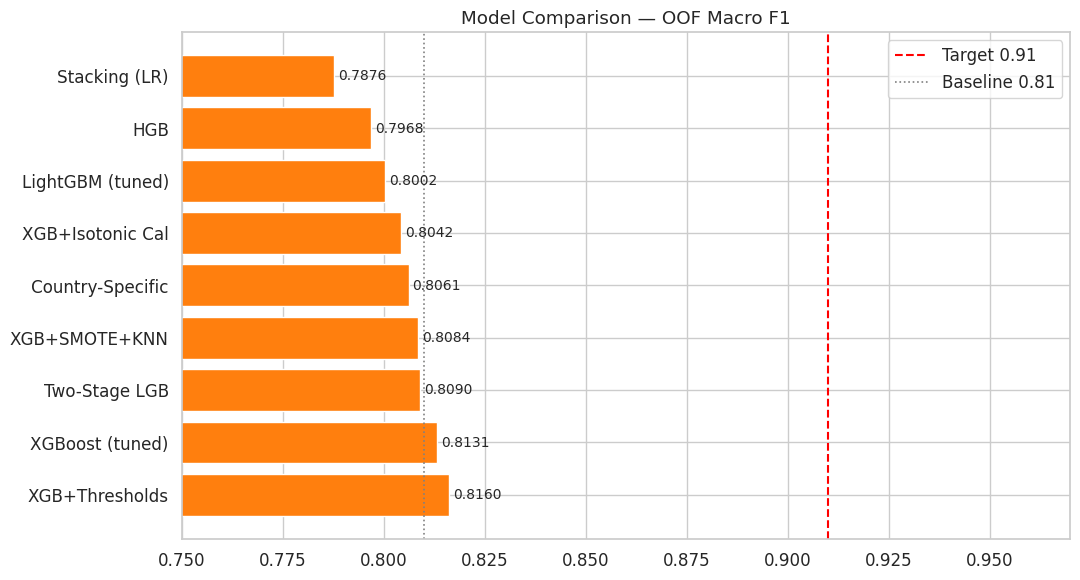

In [23]:
results = pd.DataFrame([
    ["XGBoost (tuned)",    np.mean(ll_xgb),  np.mean(f1_xgb),  np.mean(f1h_xgb)],
    ["LightGBM (tuned)",   np.mean(ll_lgb),  np.mean(f1_lgb),  np.mean(f1h_lgb)],
    ["HGB",                np.mean(ll_hgb),  np.mean(f1_hgb),  np.mean(f1h_hgb)],
    ["Two-Stage LGB",      np.mean(ts_ll),   np.mean(ts_f1),   np.mean(ts_f1h)],
    ["XGB+SMOTE+KNN",      np.mean(sm_ll),   np.mean(sm_f1),   np.mean(sm_f1h)],
    ["XGB+Isotonic Cal",   np.mean(ll_cal),  np.mean(f1_cal),  np.mean(f1h_cal)],
    ["XGB+Thresholds",     log_loss(oof_y, oof_proba), opt_f1,
                           f1_score(oof_y, apply_thresholds(oof_proba, best_thresholds), average=None)[2]],
    ["Stacking (LR)",      np.mean(meta_ll), np.mean(meta_f1), np.mean(meta_f1h)],
    ["Country-Specific",   np.mean(cs_ll),   np.mean(cs_f1),   np.mean(cs_f1h)],
], columns=["Model","LogLoss","MacroF1","HighF1"])

results = results.sort_values("MacroF1", ascending=False).reset_index(drop=True)
print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 6))
colors = ["#2ca02c" if v >= 0.91 else "#1f77b4" if v >= 0.87 else "#ff7f0e"
          for v in results["MacroF1"]]
bars = ax.barh(results["Model"], results["MacroF1"], color=colors)
ax.axvline(0.91, color="red", ls="--", lw=1.5, label="Target 0.91")
ax.axvline(0.81, color="gray", ls=":", lw=1.2, label="Baseline 0.81")
for bar, val in zip(bars, results["MacroF1"]):
    ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=10)
ax.legend(); ax.set_xlim(0.75, 0.97)
ax.set_title("Model Comparison — OOF Macro F1")
plt.tight_layout(); plt.show()


## 15. Final Ensemble: Calibrated XGB + LGB + HGB + Country Models

Pipeline:
1. Train all base models on full data
2. Build isotonic-calibrated ensemble predictions for test
3. Apply optimised per-class thresholds
4. Blend global + country-specific at 60/40


In [24]:
print("Training final models on full dataset...")

# XGB
xgb_f = xgb.XGBClassifier(**{k:v for k,v in best_xgb_params.items()
                               if k != "early_stopping_rounds"})
xgb_f.fit(X.values, y.values)
print("  XGBoost done.")

# LGB global + country-specific
lgb_global, lgb_country = train_country_models(X, y, best_lgb_params)
print(f"  LGB global + {len(lgb_country)} country models done.")

# HGB
hgb_f = HistGradientBoostingClassifier(**HGB_PARAMS)
hgb_f.fit(X, y)
print("  HGB done.")

# Two-Stage
ts_f = TwoStageClassifier()
ts_f.fit(X, y)
print("  Two-Stage done.")

# ── Optimise ensemble weights on OOF ─────────────────────────────────────────
# Country-blended LGB OOF
oof_lgb_cs = np.zeros((len(X), 3))
for c_code in X["country"].unique():
    c_mask = X["country"] == c_code
    p_g = oof_lgb[c_mask.values]
    p_c = lgb_country.get(c_code, lgb_global).predict_proba(X[c_mask])
    oof_lgb_cs[c_mask.values] = 0.6 * p_g + 0.4 * p_c

def ensemble_oof(weights):
    w = np.abs(weights); w /= w.sum()
    blend = w[0]*oof_xgb + w[1]*oof_lgb_cs + w[2]*oof_hgb
    return -f1_score(oof_stk, apply_thresholds(blend, best_thresholds), average="macro")

res_w = minimize(ensemble_oof, x0=[0.5, 0.3, 0.2], method="Nelder-Mead",
                 options={"maxiter":2000})
raw_w = np.abs(res_w.x); opt_w = raw_w / raw_w.sum()
print(f"\nOptimised weights — XGB:{opt_w[0]:.3f}  LGB:{opt_w[1]:.3f}  HGB:{opt_w[2]:.3f}")
print(f"Ensemble OOF MacroF1: {-res_w.fun:.4f}")


Training final models on full dataset...
  XGBoost done.
  LGB global + 4 country models done.
  HGB done.
  Two-Stage done.

Optimised weights — XGB:0.000  LGB:0.997  HGB:0.003
Ensemble OOF MacroF1: 0.9026


In [25]:
# ── Test predictions ──────────────────────────────────────────────────────────
xgb_test = xgb_f.predict_proba(X_test.values)
hgb_test = hgb_f.predict_proba(X_test)

# Country-blended LGB for test
lgb_test = np.zeros((len(X_test), 3))
lgb_test_g = lgb_global.predict_proba(X_test)
for c_code in X_test["country"].unique():
    c_mask = X_test["country"] == c_code
    p_c = lgb_country.get(c_code, lgb_global).predict_proba(X_test[c_mask])
    lgb_test[c_mask.values] = 0.6 * lgb_test_g[c_mask.values] + 0.4 * p_c

ensemble_test = opt_w[0]*xgb_test + opt_w[1]*lgb_test + opt_w[2]*hgb_test
final_pred    = apply_thresholds(ensemble_test, best_thresholds)
pred_labels   = [TARGET_IMAP[p] for p in final_pred]

print("Test prediction distribution:")
print(pd.Series(pred_labels).value_counts())

sub_path = f"{DATA_DIR}/../notebook/submission_v2.csv"
pd.DataFrame({"ID": test_raw["ID"], TARGET: pred_labels}).to_csv(sub_path, index=False)
print(f"Saved → {sub_path}")


Test prediction distribution:
Low       1571
Medium     728
High       106
Name: count, dtype: int64
Saved → /home/agbelgaid/Documents/WORKSPACE/Financial-Health-Prediction-Challenge/data/../notebook/submission_v2.csv


## 16. Final Error Analysis

Final OOF MacroF1 : 0.9026

              precision    recall  f1-score   support

         Low       0.96      0.95      0.95      6280
      Medium       0.87      0.90      0.89      2868
        High       0.91      0.82      0.87       470

    accuracy                           0.93      9618
   macro avg       0.91      0.89      0.90      9618
weighted avg       0.93      0.93      0.93      9618



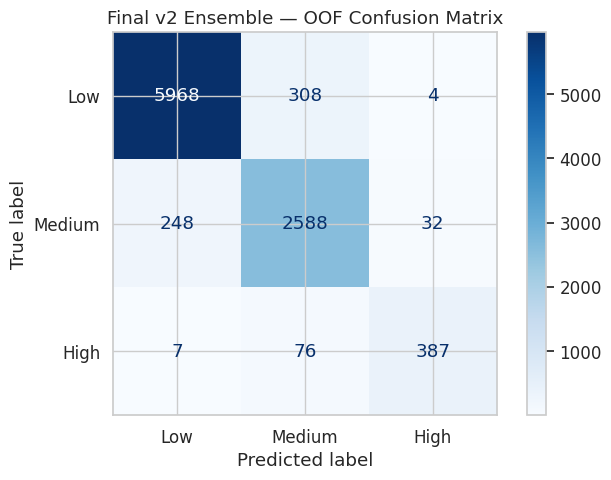

In [26]:
best_oof = opt_w[0]*oof_xgb + opt_w[1]*oof_lgb_cs + opt_w[2]*oof_hgb
best_pred= apply_thresholds(best_oof, best_thresholds)

print(f"Final OOF MacroF1 : {f1_score(oof_stk, best_pred, average='macro'):.4f}")
print()
print(classification_report(oof_stk, best_pred, target_names=["Low","Medium","High"]))

cm = confusion_matrix(oof_stk, best_pred)
fig, ax = plt.subplots(figsize=(7,5))
ConfusionMatrixDisplay(cm, display_labels=["Low","Medium","High"]).plot(
    ax=ax, cmap="Blues", colorbar=True)
ax.set_title("Final v2 Ensemble — OOF Confusion Matrix")
plt.tight_layout(); plt.show()


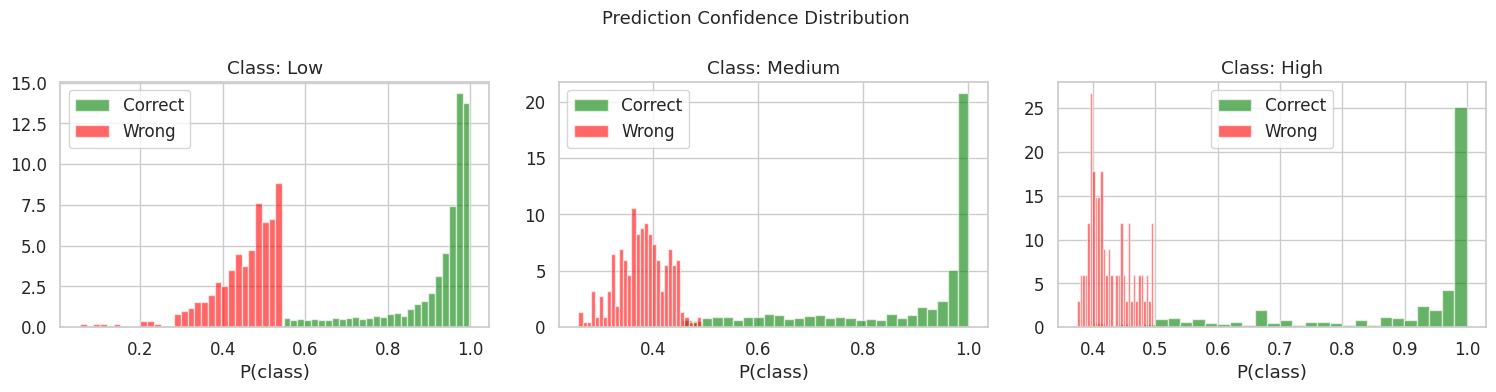

In [27]:
# Confidence distributions per class
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (cls, ax) in enumerate(zip(["Low","Medium","High"], axes)):
    mask = oof_stk == i
    c_ok  = best_oof[mask & (best_pred == oof_stk), i]
    c_bad = best_oof[mask & (best_pred != oof_stk), i]
    ax.hist(c_ok,  bins=30, alpha=0.6, color="green", label="Correct", density=True)
    ax.hist(c_bad, bins=30, alpha=0.6, color="red",   label="Wrong",   density=True)
    ax.set_title(f"Class: {cls}"); ax.set_xlabel("P(class)"); ax.legend()
plt.suptitle("Prediction Confidence Distribution", fontsize=13)
plt.tight_layout(); plt.show()
